# Caso 6

## Importacion de dependencias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Descarga del dataset

In [ ]:
import kagglehub
import pandas as pd
import os

# Descargar el dataset usando kagglehub
path = kagglehub.dataset_download("prachi13/customer-analytics")

print(f"Ruta a los archivos del dataset: {path}")

# Listar los archivos en el directorio descargado para encontrar el CSV
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    file_name = csv_files[0]
    full_file_path = os.path.join(path, file_name)

    df = pd.read_csv(full_file_path)
    print(f"Dataset '{file_name}' cargado exitosamente. Mostrando las primeras 5 filas:")
    display(df.head())
else:
    print(f"Error: No se encontraron archivos .csv en el directorio: {path}. Por favor, verifica el contenido del dataset descargado.")

Using Colab cache for faster access to the 'customer-analytics' dataset.
Ruta a los archivos del dataset: /kaggle/input/customer-analytics
Dataset 'Train.csv' cargado exitosamente. Mostrando las primeras 5 filas:


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [ ]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


## Verificacion

Verificamos que el target es el REACHED.ON.TIME Osea el alcanzado a tiempo Ya que definimos que al cliente le llego a tiempo sus pedidos

In [ ]:
target_regression = "Cost_of_the_Product"

df[target_regression].value_counts()

,count
Cost_of_the_Product,
245,110
257,109
260,106
254,101
264,100
...,...
96,5
120,5
99,5


In [ ]:
target_clasificacion= "Reached.on.Time_Y.N"
df[target_clasificacion].value_counts()


,count
Reached.on.Time_Y.N,
1,6563
0,4436


In [ ]:
df["Product_importance"].value_counts()

,count
Product_importance,
low,5297
medium,4754
high,948


In [ ]:
df["Mode_of_Shipment"].value_counts()

,count
Mode_of_Shipment,
Ship,7462
Flight,1777
Road,1760


In [ ]:
df["Warehouse_block"].value_counts()

,count
Warehouse_block,
F,3666
D,1834
A,1833
B,1833
C,1833


In [ ]:
print(f"Máximo costo del producto: {df_cleaned['Cost_of_the_Product'].max()}")
print(f"Mínimo costo del producto: {df_cleaned['Cost_of_the_Product'].min()}")

Máximo costo del producto: 310.0
Mínimo costo del producto: 96.0


#Eliminacion de variables

In [ ]:
df

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10994,10995,A,Ship,4,1,252,5,medium,F,1,1538,1
10995,10996,B,Ship,4,1,232,5,medium,F,6,1247,0
10996,10997,C,Ship,5,4,242,5,low,F,4,1155,0
10997,10998,F,Ship,5,2,223,6,medium,M,2,1210,0


In [ ]:
df_cleaned = df.drop(columns=['ID', 'Gender'])

In [ ]:


# si discount_offered>10, high discount es 1, buscamos el menos ruido posible para el entrenamiento y eliminamos discount offered
df_cleaned['High_Discount'] = (df_cleaned['Discount_offered'] > 10).astype(int)

display(df_cleaned.head())

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,High_Discount
0,D,Flight,4,2,177,3,low,44,1233,1,1
1,F,Flight,4,5,216,2,low,59,3088,1,1
2,A,Flight,2,2,183,4,low,48,3374,1,1
3,B,Flight,3,3,176,4,medium,10,1177,1,0
4,C,Flight,2,2,184,3,medium,46,2484,1,1


## Codificacion de variables categoricas

### Ordinal encoding

In [ ]:
ordinal_encoder = OrdinalEncoder(categories=[['low', 'medium', 'high']])
df_cleaned['Product_importance_encoded'] = ordinal_encoder.fit_transform(df_cleaned[['Product_importance']])

print("Valores únicos de 'Product_importance_encoded':")
print(df_cleaned['Product_importance_encoded'].value_counts())
display(df_cleaned.head())

Valores únicos de 'Product_importance_encoded':
Product_importance_encoded
0.0    5297
1.0    4754
2.0     948
Name: count, dtype: int64


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,High_Discount,Product_importance_encoded
0,D,Flight,4,2,177,3,low,44,1233,1,1,0.0
1,F,Flight,4,5,216,2,low,59,3088,1,1,0.0
2,A,Flight,2,2,183,4,low,48,3374,1,1,0.0
3,B,Flight,3,3,176,4,medium,10,1177,1,0,1.0
4,C,Flight,2,2,184,3,medium,46,2484,1,1,1.0


In [ ]:
df_encoded = df_cleaned.drop(columns=['Product_importance'])
display(df_encoded.head())

,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,High_Discount,Product_importance_encoded
0,D,Flight,4,2,177,3,44,1233,1,1,0.0
1,F,Flight,4,5,216,2,59,3088,1,1,0.0
2,A,Flight,2,2,183,4,48,3374,1,1,0.0
3,B,Flight,3,3,176,4,10,1177,1,0,1.0
4,C,Flight,2,2,184,3,46,2484,1,1,1.0


### One hot Encoding

In [ ]:
caracteristicas_categoricas_ohe = ['Warehouse_block', 'Mode_of_Shipment']

preprocesador_ohe = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), caracteristicas_categoricas_ohe)
    ],
    remainder='passthrough' # Mantener otras columnas como están
)

# Aplicar el preprocesador a df_encoded
df_procesado = preprocesador_ohe.fit_transform(df_encoded)

# Obtener nombres de características después de one-hot encoding
nombres_caracteristicas_ohe = preprocesador_ohe.named_transformers_['one_hot'].get_feature_names_out(caracteristicas_categoricas_ohe)

# Obtener nombres de las características restantes
caracteristicas_restantes = [col for col in df_encoded.columns if col not in caracteristicas_categoricas_ohe]

# Combinar todos los nombres de características
todos_nombres_caracteristicas = list(nombres_caracteristicas_ohe) + caracteristicas_restantes

# Crear un nuevo DataFrame con los datos procesados y los nombres de columna correctos
df_cleaned = pd.DataFrame(df_procesado, columns=todos_nombres_caracteristicas)

# Asegurarse de que 'Product_importance_encoded' sea numérico
df_cleaned['Product_importance_encoded'] = pd.to_numeric(df_cleaned['Product_importance_encoded'], errors='coerce')

# Convertir las columnas codificadas a enteros (0 o 1)
for col in nombres_caracteristicas_ohe:
    df_cleaned[col] = df_cleaned[col].astype(int)

display(df_cleaned.head())

,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,High_Discount,Product_importance_encoded
0,0,0,0,1,0,1,0,0,4.0,2.0,177.0,3.0,44.0,1233.0,1.0,1.0,0.0
1,0,0,0,0,1,1,0,0,4.0,5.0,216.0,2.0,59.0,3088.0,1.0,1.0,0.0
2,1,0,0,0,0,1,0,0,2.0,2.0,183.0,4.0,48.0,3374.0,1.0,1.0,0.0
3,0,1,0,0,0,1,0,0,3.0,3.0,176.0,4.0,10.0,1177.0,1.0,0.0,1.0
4,0,0,1,0,0,1,0,0,2.0,2.0,184.0,3.0,46.0,2484.0,1.0,1.0,1.0


## EDA
Analis exploratorio de datos

### Eliminacion de variables

### Correlacion entre vairiables

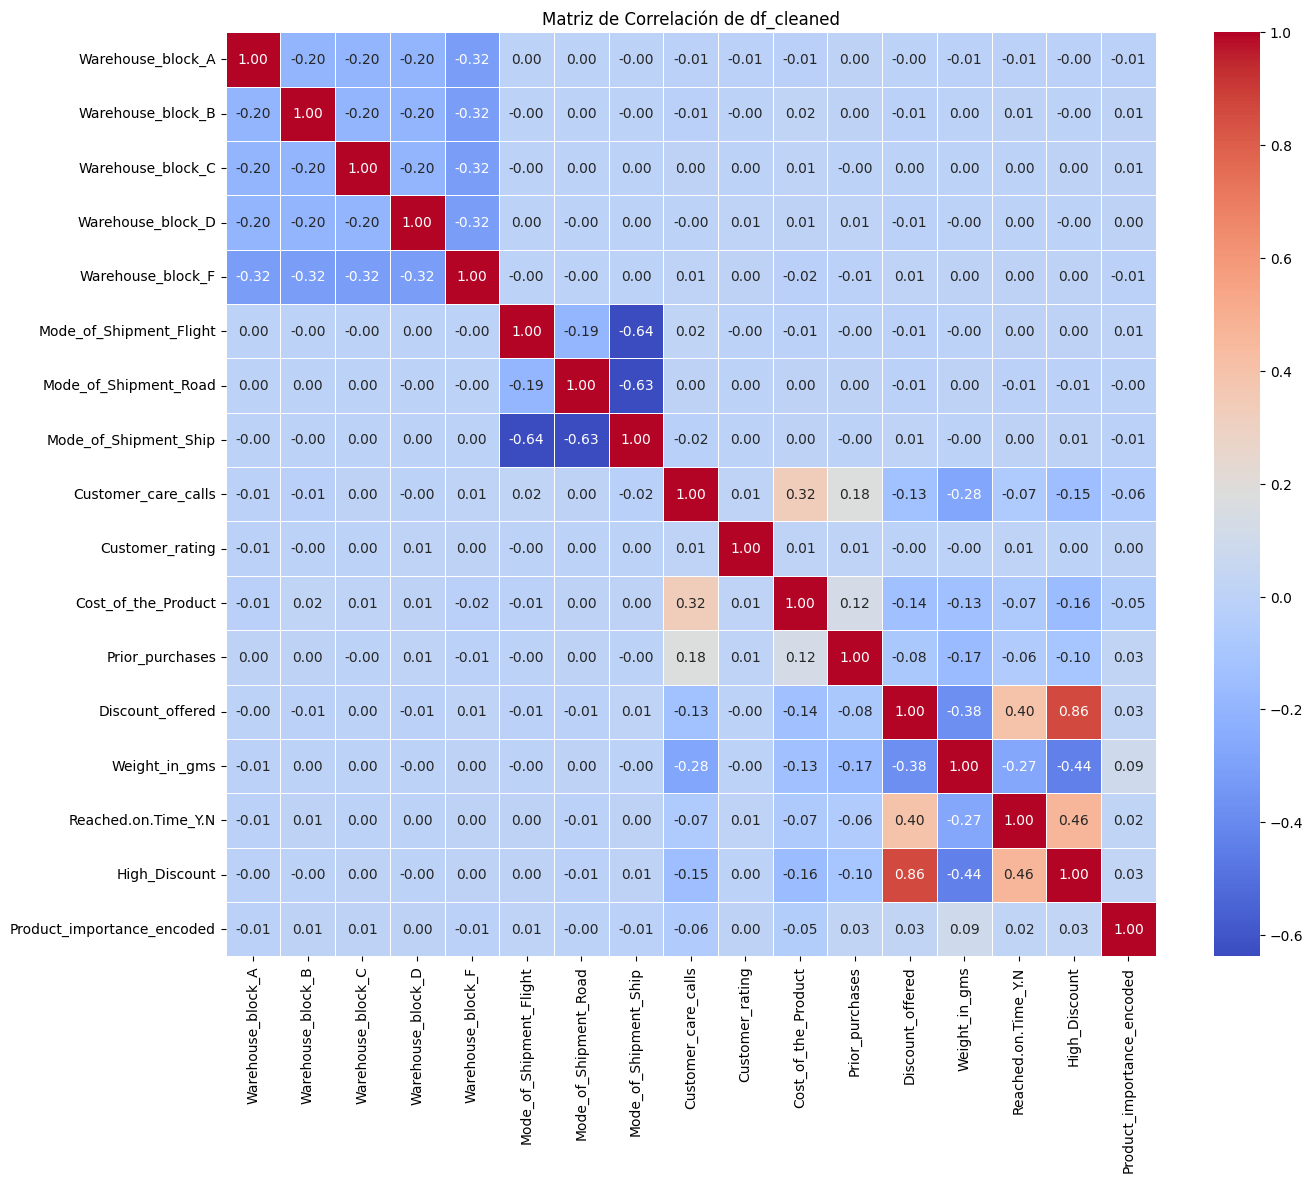

In [ ]:
plt.figure(figsize=(15, 12))
sns.heatmap(df_cleaned.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de df_cleaned')
plt.show()

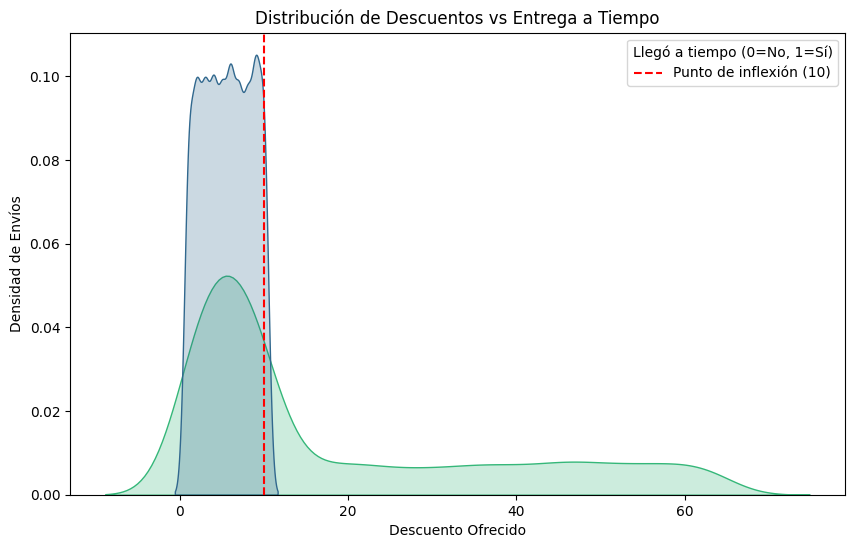

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Discount_offered', hue='Reached.on.Time_Y.N', fill=True, common_norm=False, palette='viridis')
plt.axvline(10, color='red', linestyle='--', label='Punto de inflexión (10)')
plt.title('Distribución de Descuentos vs Entrega a Tiempo')
plt.xlabel('Descuento Ofrecido')
plt.ylabel('Densidad de Envíos')
plt.legend(title='Llegó a tiempo (0=No, 1=Sí)')
plt.show()

In [ ]:
df_cleaned = df_cleaned.drop(columns=['Discount_offered'])

### Distribucion de variables
El propósito de esta gráfica es mostrar cómo se distribuyen los valores de las variables numéricas en el conjunto de datos. Esto permite observar patrones, identificar posibles valores atípicos y entender el comportamiento general de los datos antes de aplicar modelos de análisis o aprendizaje automático.

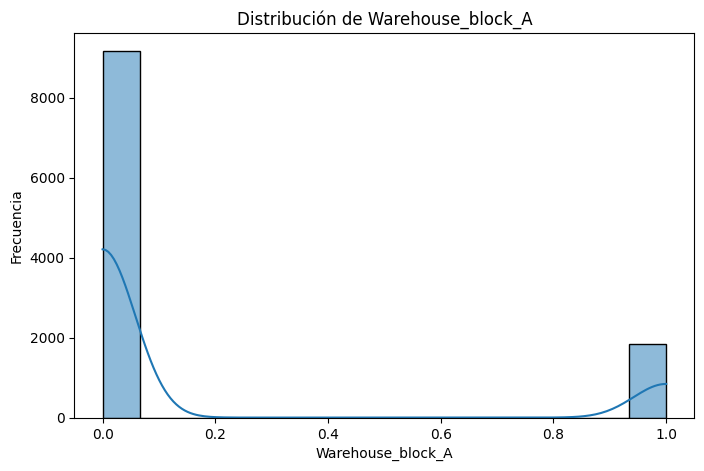

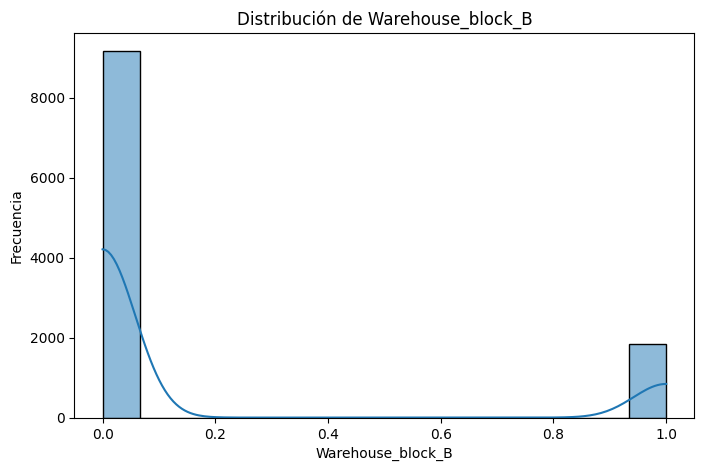

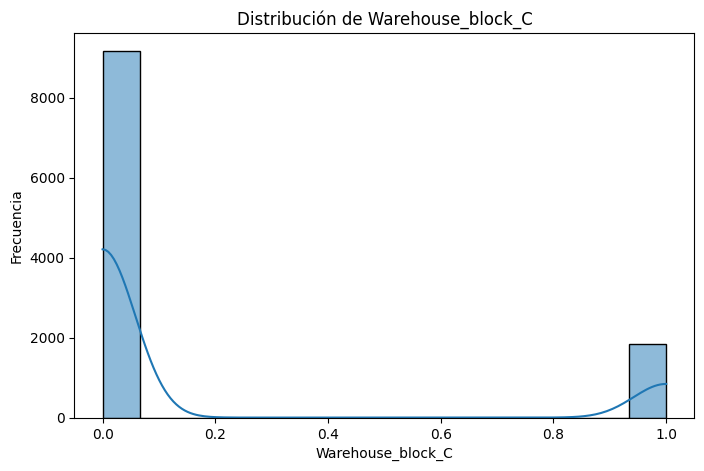

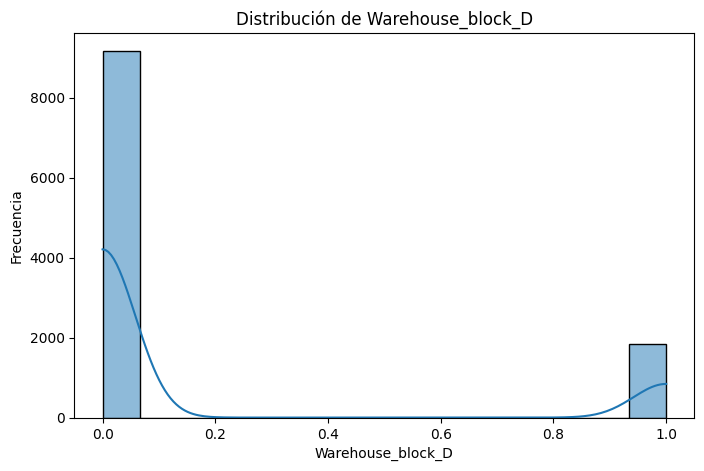

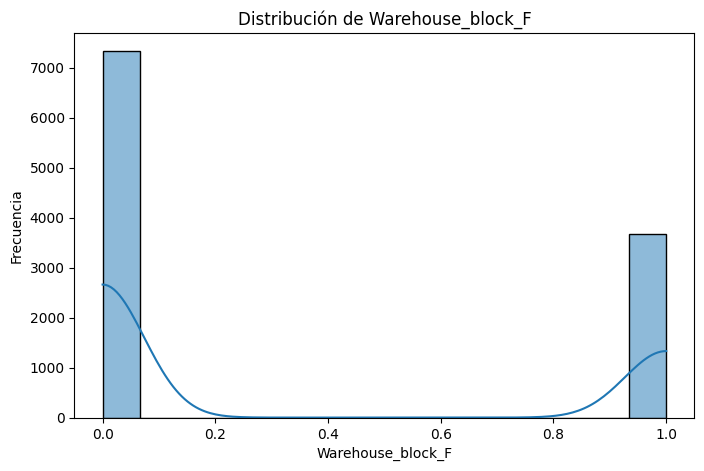

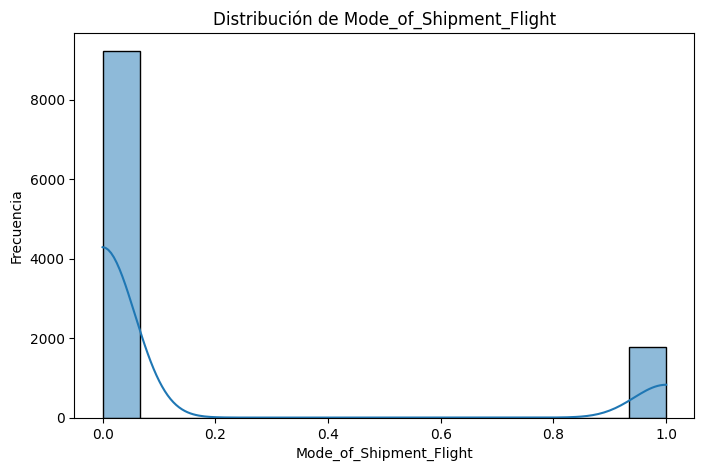

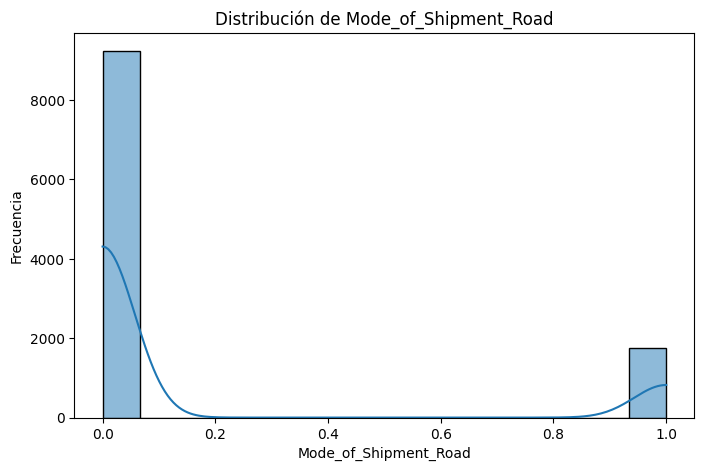

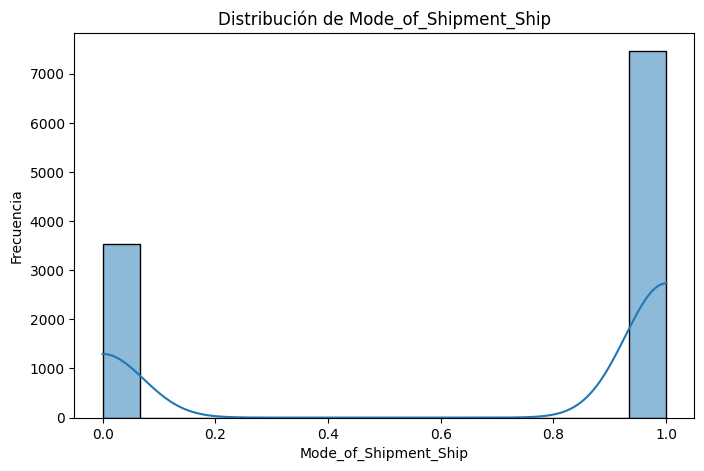

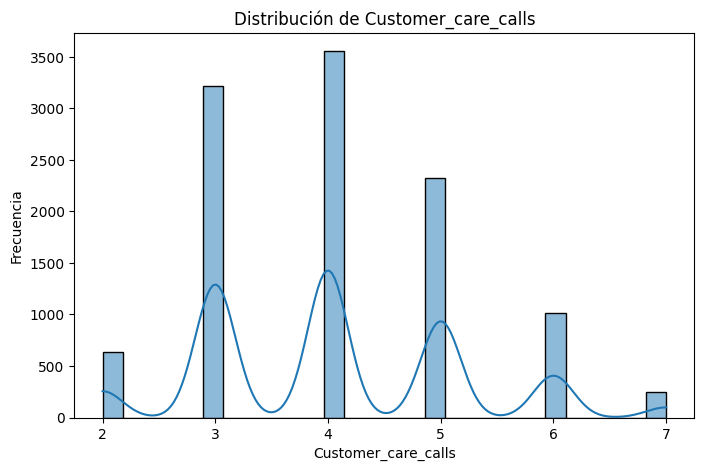

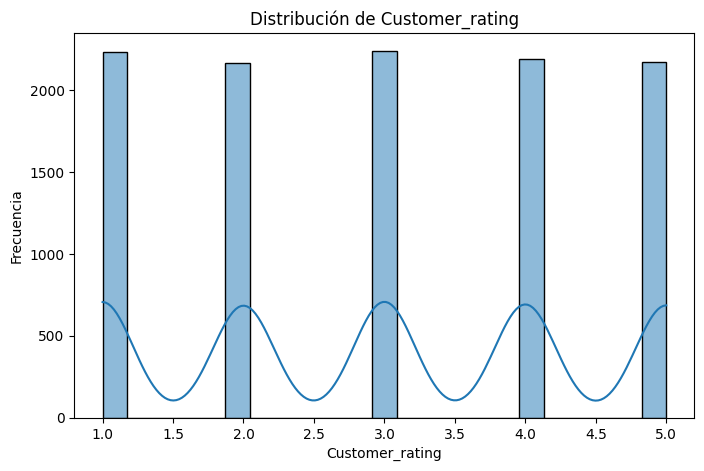

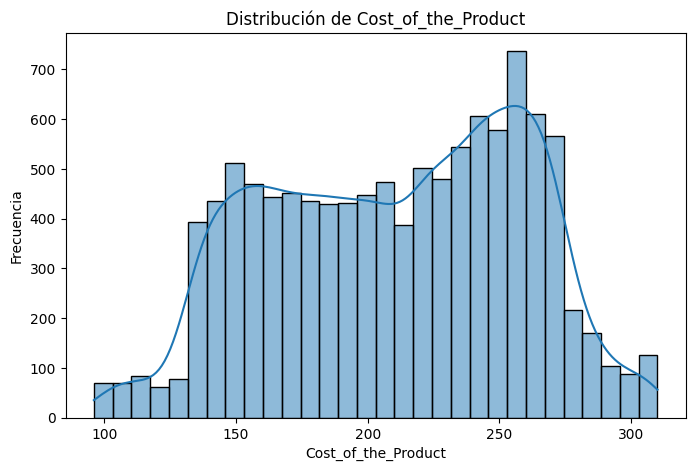

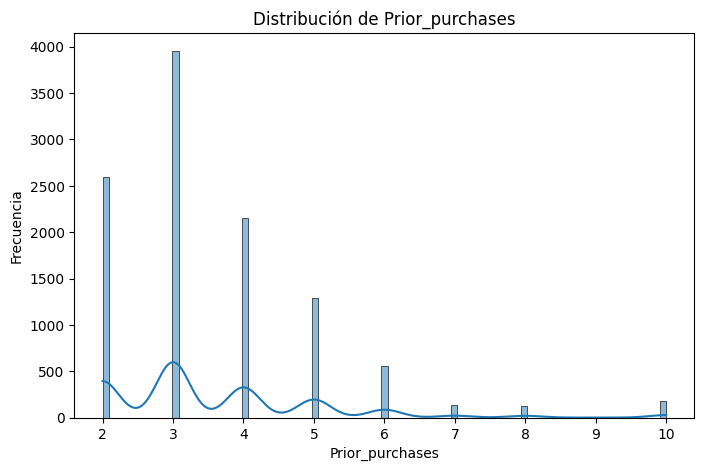

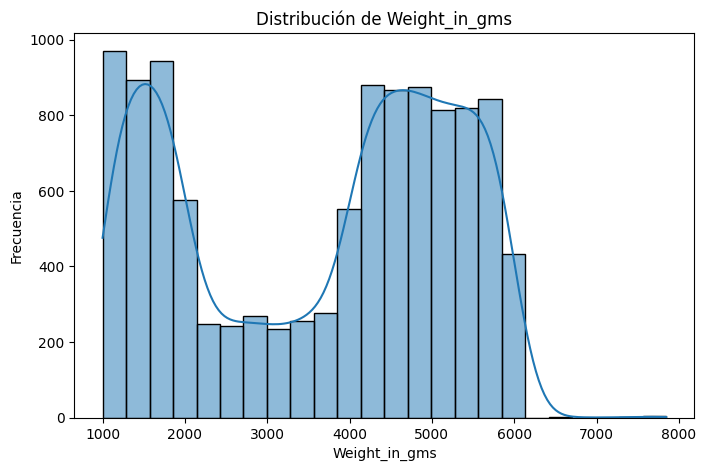

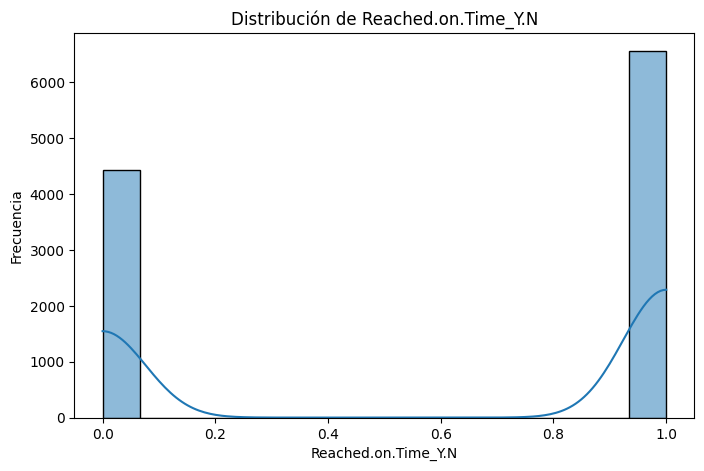

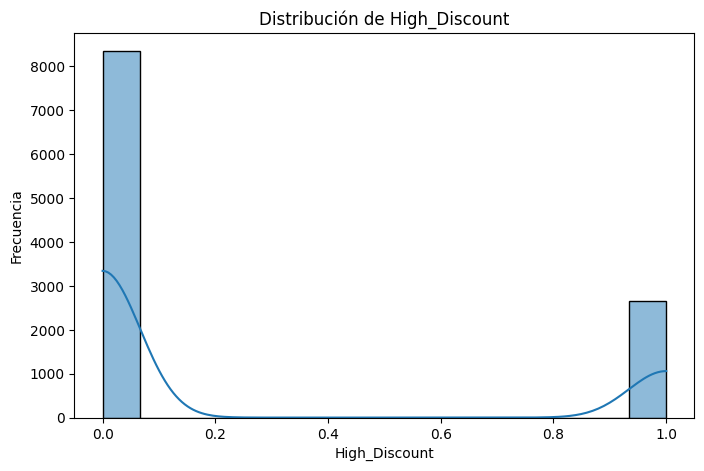

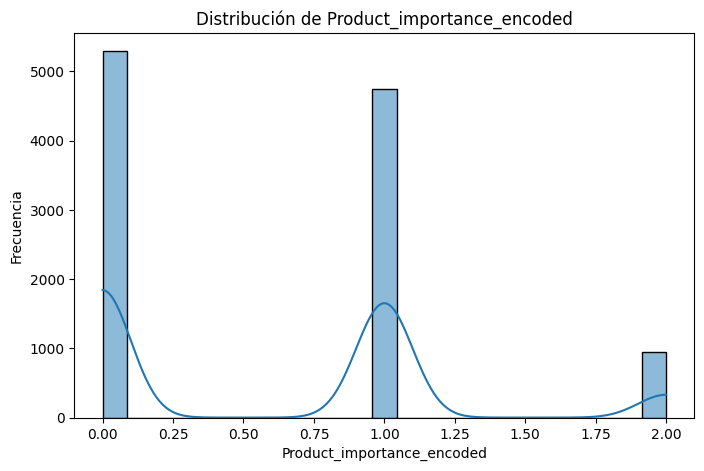

In [ ]:
for col in df_cleaned.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

### Análisis de Dispersión y Detección de Valores Atípicos
El propósito de esta gráfica es identificar la dispersión de los datos y detectar posibles valores atípicos en las variables numéricas del conjunto de datos. El boxplot permite observar la mediana, los rangos de los datos y los valores extremos, lo que ayuda a comprender la variabilidad de cada variable y a detectar datos que podrían afectar el análisis o los modelos de aprendizaje automático.

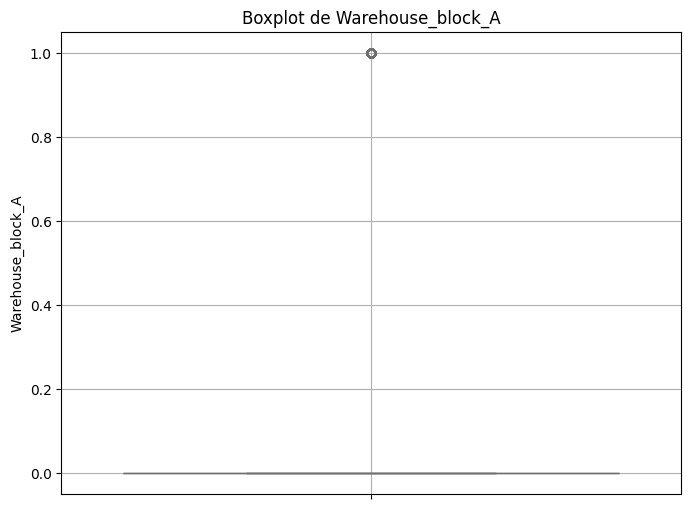

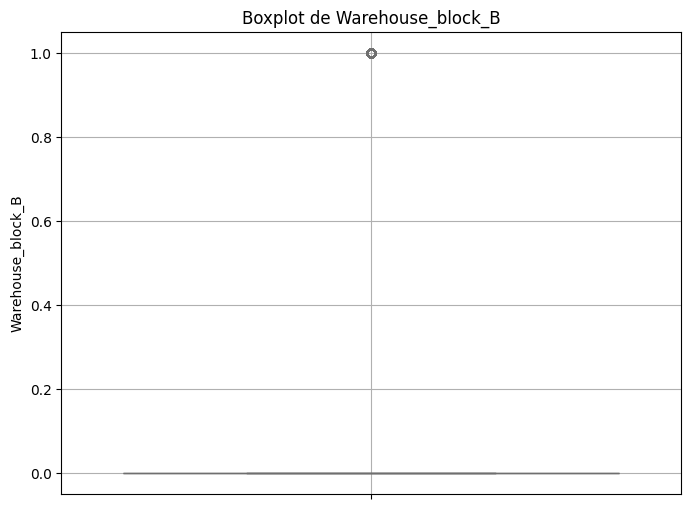

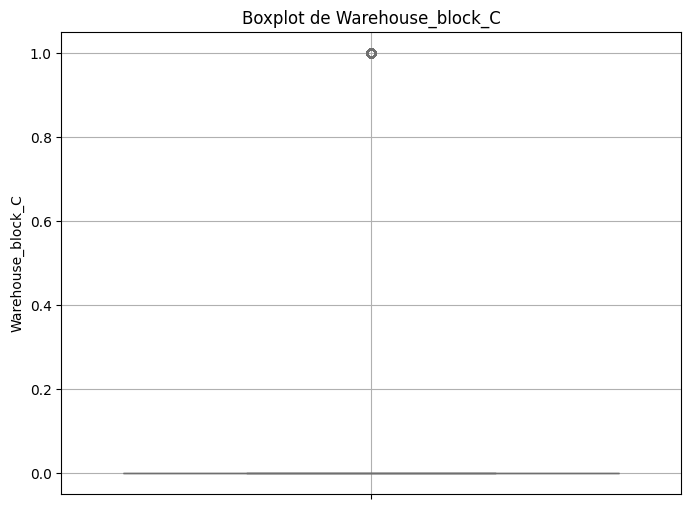

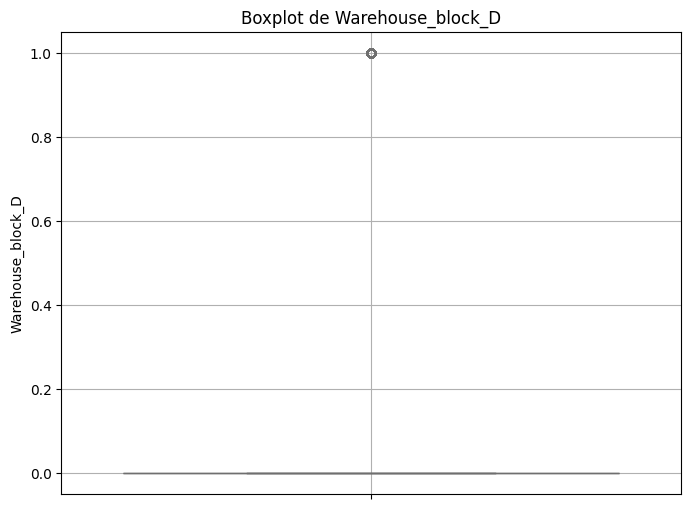

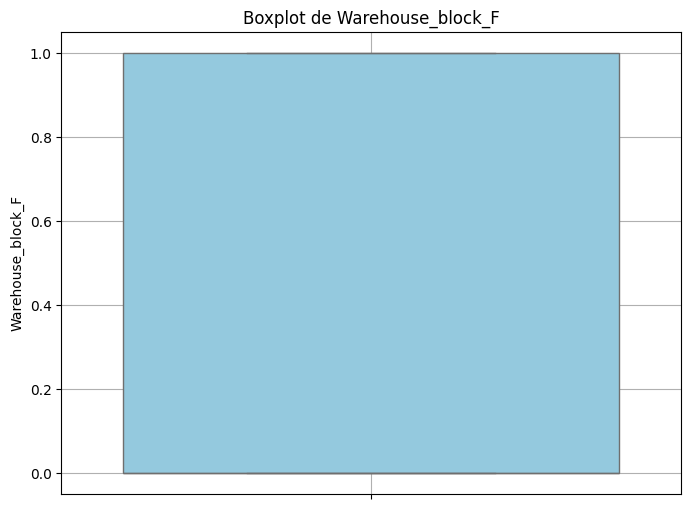

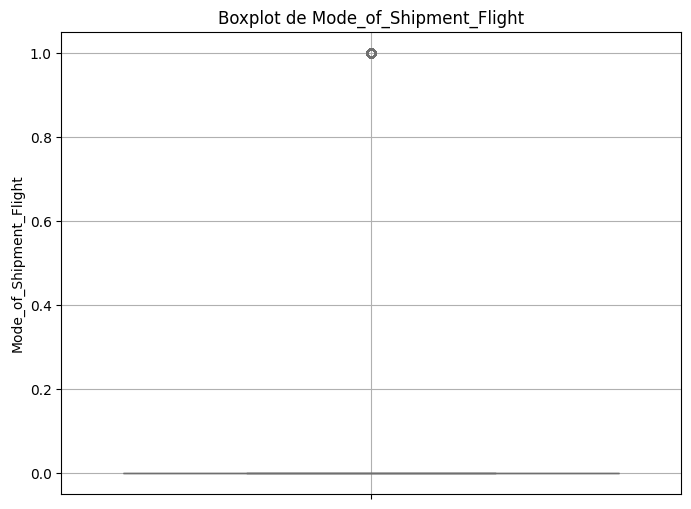

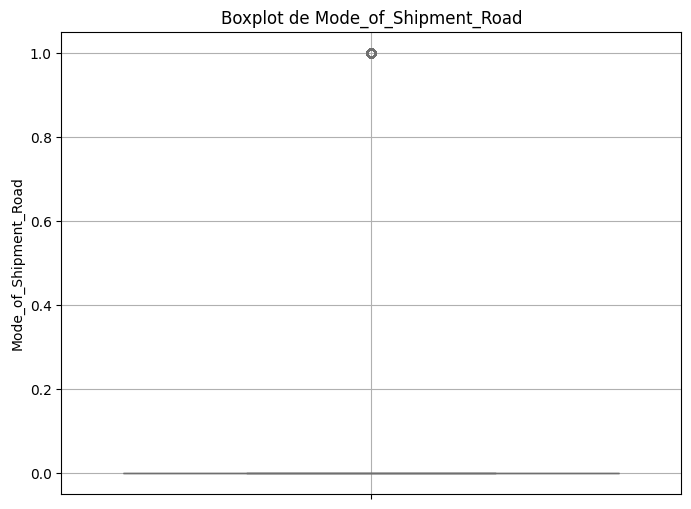

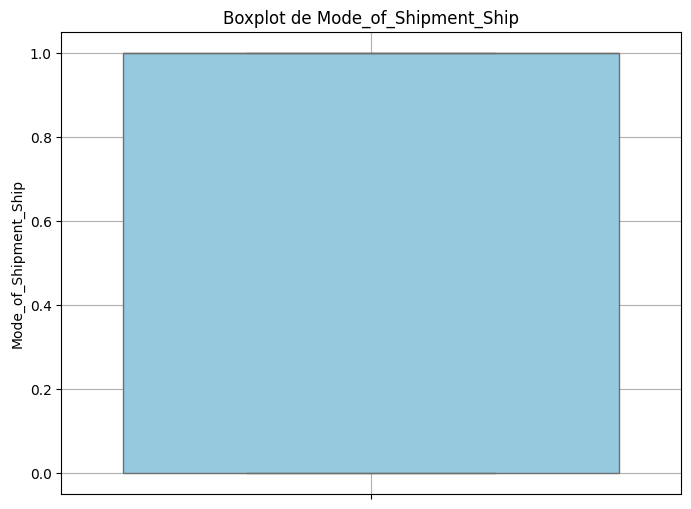

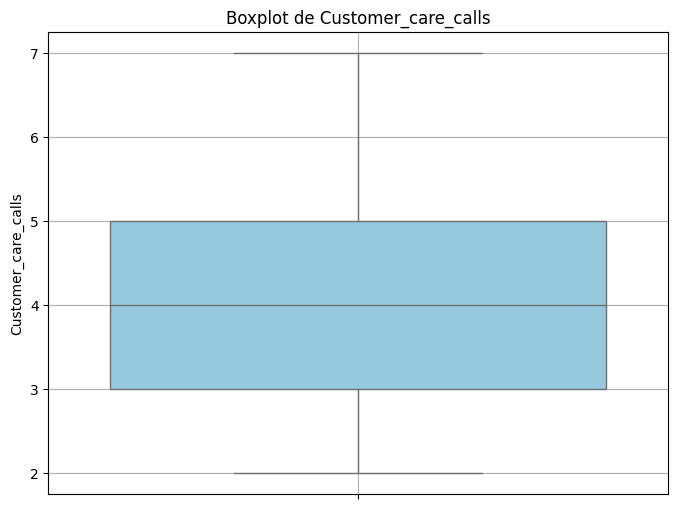

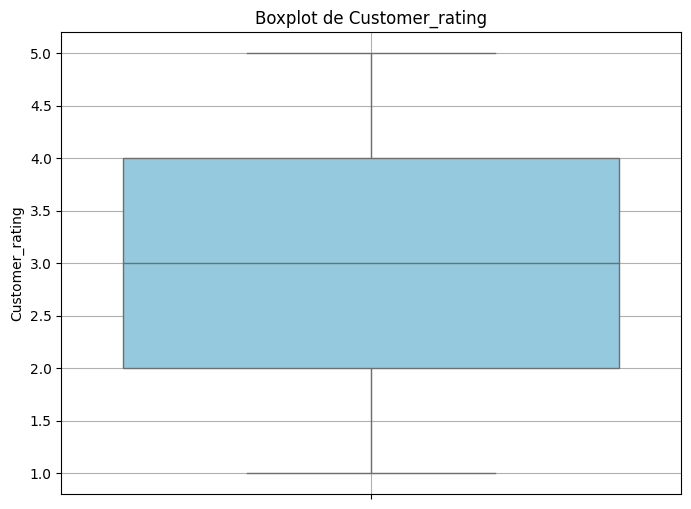

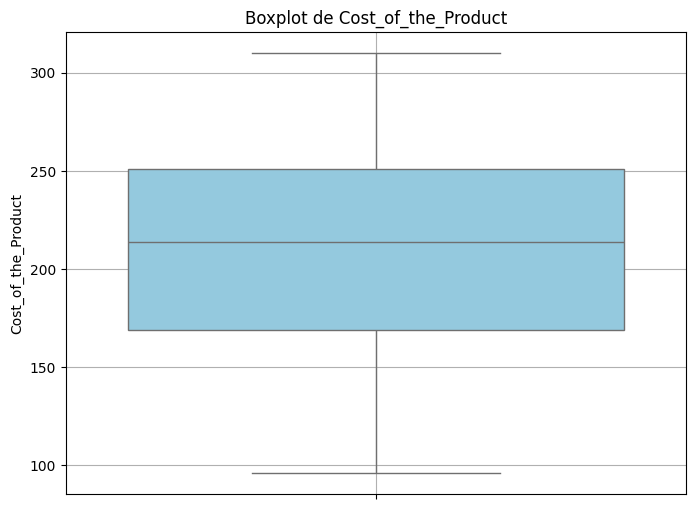

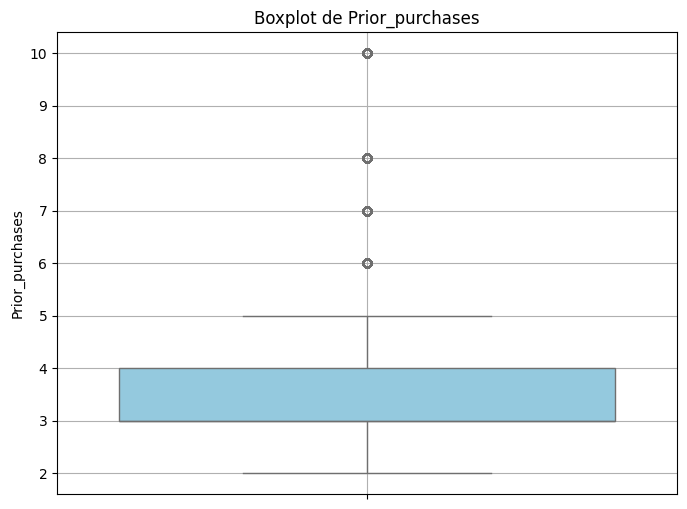

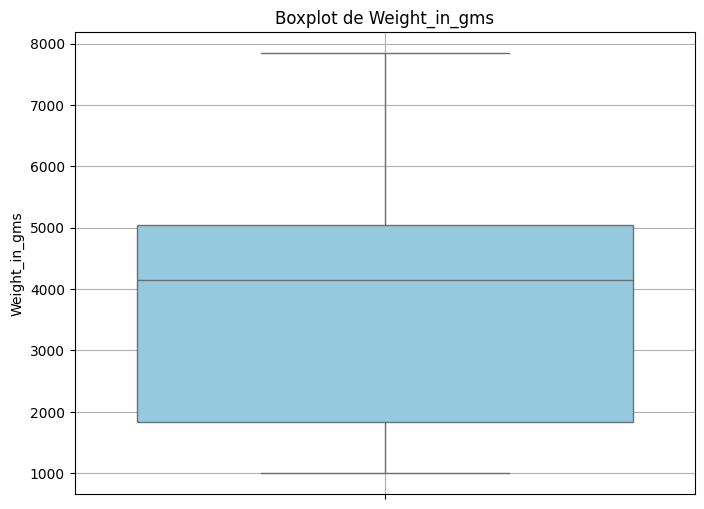

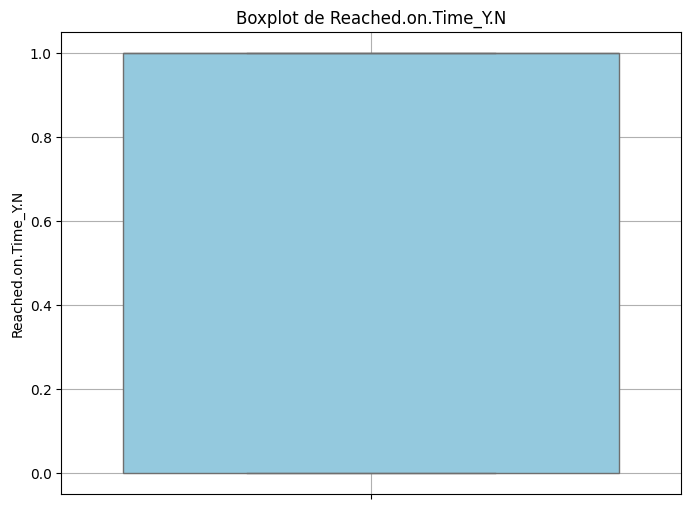

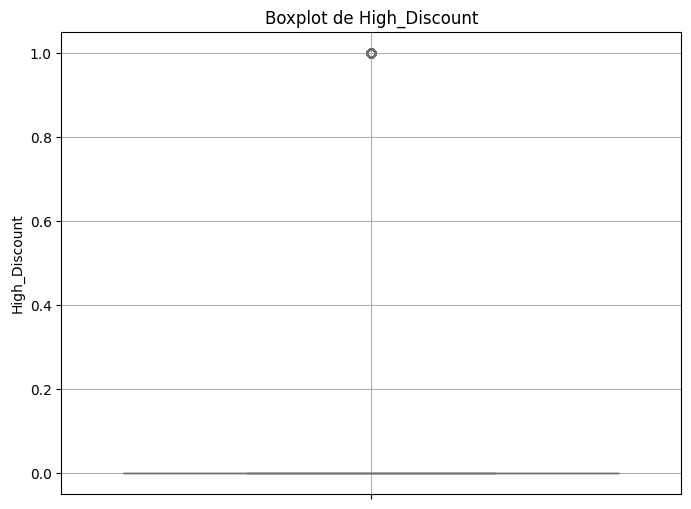

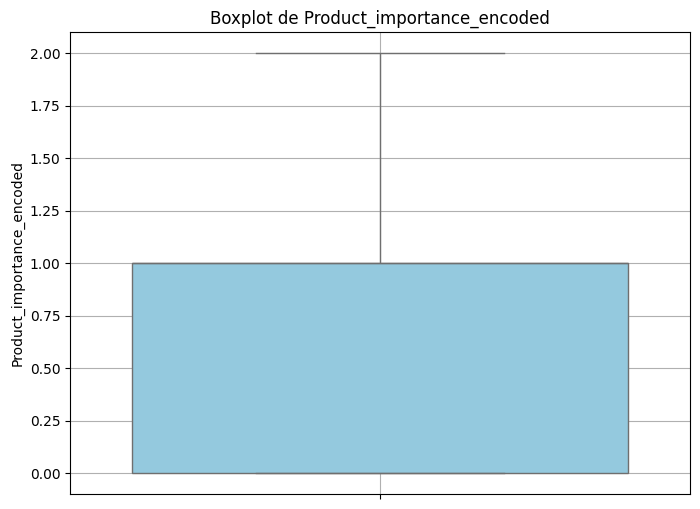

In [ ]:
numeric_columns = df_cleaned.select_dtypes(include=['int64', 'float64']).columns


for column in numeric_columns:
    plt.figure(figsize=(8, 6)) # Adjust figure size as needed
    sns.boxplot(y=df_cleaned[column], color='skyblue')  # Boxplot vertical
    plt.title(f'Boxplot de {column}')
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

Prior purchases presenta muchos outliers, pero es entendible si consideramos el modelo de negocio

## Entrenamiento de modelo

### Regresion lineal en cost of the product

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

X = df_cleaned.drop(columns=['Cost_of_the_Product', 'Reached.on.Time_Y.N'])
y = df_cleaned['Cost_of_the_Product']

# Para aplicar estratificación a una variable continua, necesitamos crear bins
# Se crean 5 bins para el Cost_of_the_Product
y_binned = pd.cut(y, bins=5, labels=False, include_lowest=True)

# Split the data into training and testing sets, stratifying by the binned target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=42, stratify=y_binned)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (9899, 15)
y_train shape: (9899,)
X_test shape: (1100, 15)
y_test shape: (1100,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
linear_model_cost = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model_cost.fit(X_train, y_train)

y_pred_linear_cost = linear_model_cost.predict(X_test)

mae_linear_cost = mean_absolute_error(y_test, y_pred_linear_cost)
rmse_linear_cost = np.sqrt(mean_squared_error(y_test, y_pred_linear_cost))

print("=== REGRESIÓN LINEAL para Cost_of_the_Product ===")
print("MAE:", mae_linear_cost)
print("RMSE:", rmse_linear_cost)

=== REGRESIÓN LINEAL para Cost_of_the_Product ===
MAE: 36.49870370639957
RMSE: 43.87905198454527


In [ ]:
from sklearn.metrics import r2_score

r2_linear_cost = r2_score(y_test, y_pred_linear_cost)
print(f"R-squared para el modelo de Regresión Lineal (Cost_of_the_Product): {r2_linear_cost:.4f}")

R-squared para el modelo de Regresión Lineal (Cost_of_the_Product): 0.1783


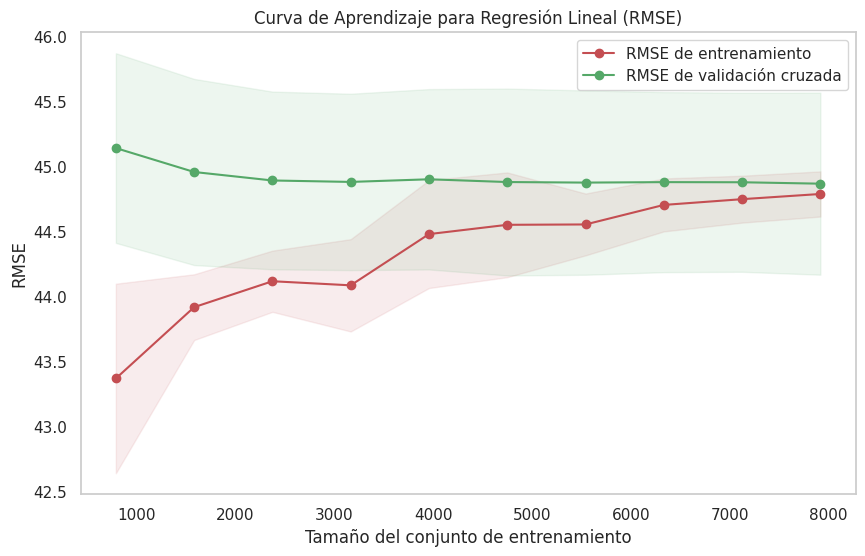

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_squared_error

# Obtener el modelo de Regresión Lineal del pipeline
model_for_learning_curve_reg = linear_model_cost.named_steps['model']

# Generar la curva de aprendizaje para regresión
train_sizes_reg, train_scores_reg, val_scores_reg = learning_curve(
    model_for_learning_curve_reg, X_train, y_train, cv=5, scoring='neg_mean_squared_error',
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Calcular medias y desviaciones estándar, y convertir a RMSE
train_scores_mean_reg = np.sqrt(-np.mean(train_scores_reg, axis=1))
train_scores_std_reg = np.std(np.sqrt(-train_scores_reg), axis=1)
val_scores_mean_reg = np.sqrt(-np.mean(val_scores_reg, axis=1))
val_scores_std_reg = np.std(np.sqrt(-val_scores_reg), axis=1)

# Plotear la curva de aprendizaje
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes_reg, train_scores_mean_reg - train_scores_std_reg,
                 train_scores_mean_reg + train_scores_std_reg, alpha=0.1, color="r")
plt.fill_between(train_sizes_reg, val_scores_mean_reg - val_scores_std_reg,
                 val_scores_mean_reg + val_scores_std_reg, alpha=0.1, color="g")
plt.plot(train_sizes_reg, train_scores_mean_reg, 'o-', color="r", label="RMSE de entrenamiento")
plt.plot(train_sizes_reg, val_scores_mean_reg, 'o-', color="g", label="RMSE de validación cruzada")

plt.title("Curva de Aprendizaje para Regresión Lineal (RMSE)")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("RMSE")
plt.legend(loc="best")
plt.grid()
plt.show()

Considerando las métricas obtenidas (R² = 0.1785, MAE ≈ 36.4 y RMSE ≈ 43.8), se observa que el modelo de regresión lineal presenta una baja capacidad explicativa, ya que solo logra explicar aproximadamente el 10% de la variabilidad del costo del producto.

Si bien los valores de MAE y RMSE parecen bajos, estos se encuentran en una escala estandarizada, por lo que representan errores relativos dentro de la distribución transformada del target. A pesar de ello, el valor reducido de R² confirma que el modelo no está capturando adecuadamente la relación entre las variables predictoras y el costo del producto.

La similitud en el desempeño sugiere que el problema no radica en la optimización del modelo, sino en la limitada capacidad informativa del dataset. Para mejorar la predicción, sería necesario incorporar nuevas características más directamente relacionadas con la formación del precio (como categoría del producto, tipo, calidad, marca u otros atributos comerciales) o emplear modelos no lineales capaces de capturar relaciones más complejas entre las variables.

### Regresion con metodo Rigde

In [ ]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("=== RIDGE para Cost_of_the_Product ===")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)

=== RIDGE para Cost_of_the_Product ===
MAE: 36.498977782047035
RMSE: 43.879092552695354


### Comparacion entre ambos de Linear y Ridge

In [ ]:
comparison = pd.DataFrame({
    "Modelo": ["Linear Regression", "Ridge"],
    "MAE": [mae_linear_cost, mae_ridge],
    "RMSE": [rmse_linear_cost, rmse_ridge]
})

comparison

,Modelo,MAE,RMSE
0,Linear Regression,36.498704,43.879052
1,Ridge,36.498978,43.879093


###Lasso


In [ ]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=1.0, max_iter=1000))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("=== LASSO para Cost_of_the_Product ===")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)

=== LASSO para Cost_of_the_Product ===
MAE: 36.90666941741739
RMSE: 44.11034341175346


In [ ]:
comparison = pd.concat([comparison, pd.DataFrame([{"Modelo": "Lasso", "MAE": mae_lasso, "RMSE": rmse_lasso}])], ignore_index=True)
display(comparison)

,Modelo,MAE,RMSE
0,Linear Regression,36.498704,43.879052
1,Ridge,36.498978,43.879093
2,Lasso,36.906669,44.110343


Todos los modelos evaluados, incluyendo la regresión lineal regularizada con Ridge y Lasso, presentan resultados muy similares en términos de desempeño. Esto sugiere que la limitación principal no radica en el tipo de modelo utilizado, sino en la capacidad explicativa del dataset.

En otras palabras, las variables disponibles no contienen suficiente información relevante para predecir adecuadamente el costo del producto, por lo que cambiar o regularizar el modelo no genera mejoras significativas.

##Clasificacion

In [ ]:

X_clf = df_cleaned.drop(columns=['Cost_of_the_Product', 'Reached.on.Time_Y.N'])
y_clf = df_cleaned['Reached.on.Time_Y.N']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.15, random_state=42, stratify=y_clf)

print(f"X_train_clf shape: {X_train_clf.shape}")
print(f"y_train_clf shape: {y_train_clf.shape}")
print(f"X_test_clf shape: {X_test_clf.shape}")
print(f"y_test_clf shape: {y_test_clf.shape}")

X_train_clf shape: (9349, 15)
y_train_clf shape: (9349,)
X_test_clf shape: (1650, 15)
y_test_clf shape: (1650,)


=== CLASIFICACIÓN con ÁRBOLES DE DECISIÓN ===
Precisión: 0.6794

Matriz de Confusión:
[[628  37]
 [492 493]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.56      0.94      0.70       665
         1.0       0.93      0.50      0.65       985

    accuracy                           0.68      1650
   macro avg       0.75      0.72      0.68      1650
weighted avg       0.78      0.68      0.67      1650



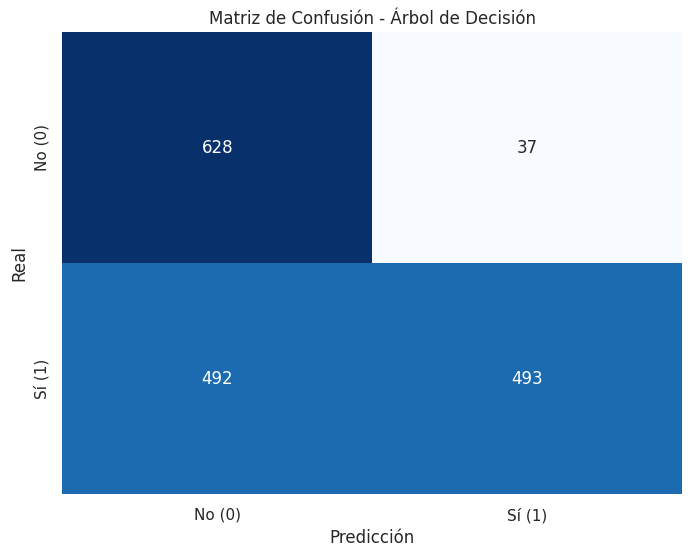

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo_arbol_decision = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", DecisionTreeClassifier(max_depth=8, min_samples_split=10, min_samples_leaf=10, random_state=42))
])

modelo_arbol_decision.fit(X_train_clf, y_train_clf)

y_pred_dt = modelo_arbol_decision.predict(X_test_clf)

# Evaluar el modelo
precision_dt = accuracy_score(y_test_clf, y_pred_dt)
matriz_confusion_dt = confusion_matrix(y_test_clf, y_pred_dt)
reporte_clasificacion_dt = classification_report(y_test_clf, y_pred_dt)

print("=== CLASIFICACIÓN con ÁRBOLES DE DECISIÓN ===")
print(f"Precisión: {precision_dt:.4f}")
print("\nMatriz de Confusión:")
print(matriz_confusion_dt)
print("\nReporte de Clasificación:")
print(reporte_clasificacion_dt)

# Visualizar Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusion_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No (0)', 'Sí (1)'], yticklabels=['No (0)', 'Sí (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

Verdaderos Negativos (TN): 627
El modelo predijo correctamente '0' (No llegó a tiempo / Retraso). Es muy sólido identificando los problemas logísticos.

Falsos Positivos (FP): 38
El modelo predijo incorrectamente '1' (Llegó a tiempo), cuando en realidad hubo un retraso. Estos son "falsas promesas" al cliente.

Falsos Negativos (FN): 491
El modelo predijo incorrectamente '0' (Retraso), cuando en realidad el paquete sí llegó a tiempo. Estás siendo demasiado pesimista con casi 500 envíos.

Verdaderos Positivos (TP): 494
El modelo predijo correctamente '1' (Llegó a tiempo). Logra capturar aproximadamente la mitad de los éxitos.

Clase 0.0 (No llegó a tiempo / Retraso):
El modelo tiene una precisión de 0.56, lo que significa que cuando el sistema marca un "Retraso", solo tiene razón el 56% de las veces (debido a la gran cantidad de Falsos Negativos). Sin embargo, su recall es altísimo (0.94), lo que indica que es casi infalible detectando los retrasos reales: se le escapan muy pocos. Su F1-score es de 0.70.

Clase 1.0 (Llegó a tiempo):
Para esta clase, el modelo muestra una precisión excelente (0.93). Esto es vital para el negocio: si el modelo dice "tu paquete llega hoy", puedes confiar en ello casi a ciegas (93% de certeza). No obstante, su recall es bajo (0.50), lo que significa que el modelo es tan "tímido" que solo se atreve a predecir un éxito en la mitad de los casos que realmente lo son. Su F1-score es de 0.65.


##Random forest

=== CLASIFICACIÓN con RANDOM FOREST ===
Precisión: 0.6739

Matriz de Confusión:
[[653  12]
 [526 459]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.55      0.98      0.71       665
         1.0       0.97      0.47      0.63       985

    accuracy                           0.67      1650
   macro avg       0.76      0.72      0.67      1650
weighted avg       0.80      0.67      0.66      1650



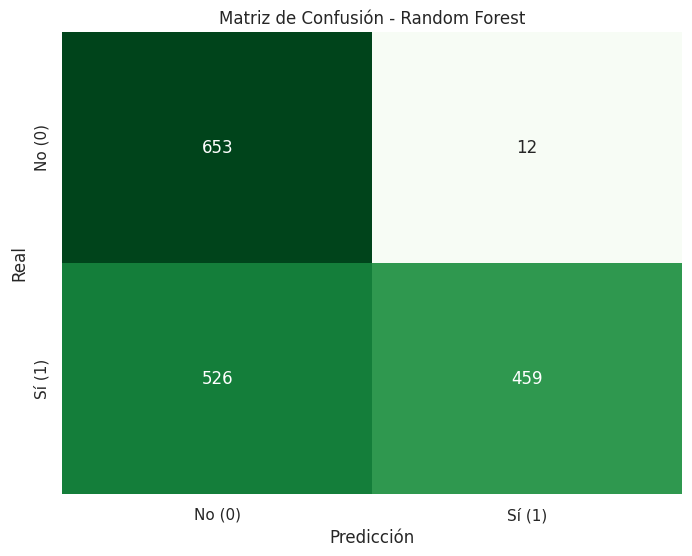

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

modelo_random_forest = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", RandomForestClassifier(
        n_estimators=150,          # Más árboles para mayor estabilidad
        max_depth=8,              # Mayor profundidad para captar más patrones
        min_samples_split=10,       # Permitir divisiones más granulares
        min_samples_leaf=10,        # Hojas más pequeñas
        max_features=0.5,           # Diversidad entre árboles
        bootstrap=True,            # Usar muestras aleatorias del dataset
        random_state=42,
        class_weight='balanced'
    ))
])

modelo_random_forest.fit(X_train_clf, y_train_clf)

y_pred_rf = modelo_random_forest.predict(X_test_clf)

# Evaluar el modelo
precision_rf = accuracy_score(y_test_clf, y_pred_rf)
matriz_confusion_rf = confusion_matrix(y_test_clf, y_pred_rf)
reporte_clasificacion_rf = classification_report(y_test_clf, y_pred_rf)

print("=== CLASIFICACIÓN con RANDOM FOREST ===")
print(f"Precisión: {precision_rf:.4f}")
print("\nMatriz de Confusión:")
print(matriz_confusion_rf)
print("\nReporte de Clasificación:")
print(reporte_clasificacion_rf)

# Visualizar Matriz de Confusión
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusion_rf, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No (0)', 'Sí (1)'], yticklabels=['No (0)', 'Sí (1)'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

Verdaderos Negativos (TN): 652 (El modelo predijo correctamente '0' - No llegó a tiempo).

Falsos Positivos (FP): 13 (El modelo predijo incorrectamente '1' - Llegó a tiempo, cuando en realidad fue '0').

Falsos Negativos (FN): 527 (El modelo predijo incorrectamente '0' - No llegó a tiempo, cuando en realidad fue '1').

Verdaderos Positivos (TP): 458 (El modelo predijo correctamente '1' - Llegó a tiempo).

##Interpretacion de resultados

Interpretación:

Clase 0.0 (No llegó a tiempo): El modelo tiene una precisión de 0.55, lo que significa que cuando predice que un paquete no llegará a tiempo, es correcto el 55% de las veces. Sin embargo, su recall es muy alto (0.98), indicando que identifica correctamente el 98% de todos los casos reales de 'No llegó a tiempo'. El F1-score es 0.71.

Clase 1.0 (Llegó a tiempo): Para esta clase, el modelo muestra una precisión muy alta (0.97), lo que significa que cuando predice que un paquete sí llegará a tiempo, es correcto el 97% de las veces. Pero su recall es considerablemente más bajo (0.46), indicando que solo identifica correctamente el 46% de todos los casos reales de 'Llegó a tiempo'. El F1-score es 0.63.

Comparación con el Árbol de Decisión: El modelo de Random Forest tiene una precisión similar al Árbol de Decisión (0.6727 vs 0.6794), pero muestra un patrón diferente en la matriz de confusión. Mientras que el Árbol de Decisión tenía un recall muy alto para la clase 0 y más bajo para la clase 1, el Random Forest logra una precisión muy alta para la clase 1, a expensas de un recall más bajo. Esto sugiere que el Random Forest es muy bueno para evitar falsos positivos en la predicción de entregas a tiempo, pero falla en identificar casi la mitad de los casos donde sí se entrega a tiempo.

Ambos modelos, hasta ahora, muestran un rendimiento moderado en la tarea de clasificación, y la elección entre ellos dependería de si es más crítico minimizar los falsos positivos o los falsos negativos para cada clase.

/tmp/ipykernel_343/4261313888.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Reached.on.Time_Y.N', data=df_cleaned, ax=ax[0], palette='viridis')


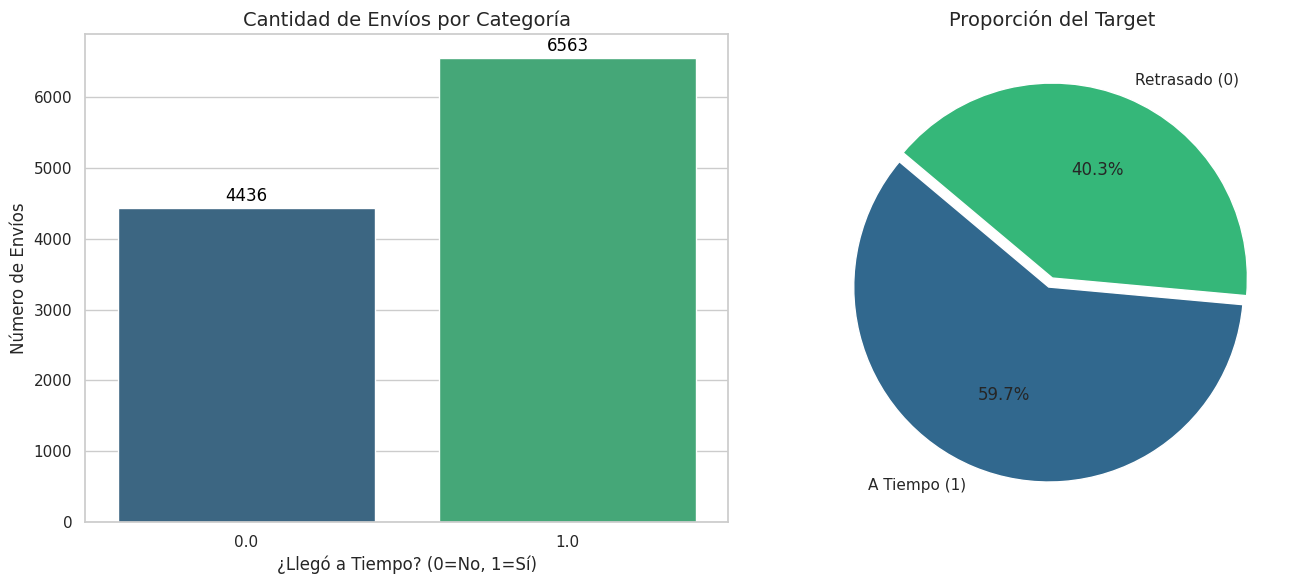

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# 1. Gráfico de Barras
sns.countplot(x='Reached.on.Time_Y.N', data=df_cleaned, ax=ax[0], palette='viridis')
ax[0].set_title('Cantidad de Envíos por Categoría', fontsize=14)
ax[0].set_xlabel('¿Llegó a Tiempo? (0=No, 1=Sí)')
ax[0].set_ylabel('Número de Envíos')


for p in ax[0].patches:
    ax[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                   textcoords='offset points')

# 2. Gráfico de Pastel (Proporción porcentual)
counts = df_cleaned['Reached.on.Time_Y.N'].value_counts()
ax[1].pie(counts, labels=['A Tiempo (1)', 'Retrasado (0)'], autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('viridis', 2), explode=(0.05, 0))
ax[1].set_title('Proporción del Target', fontsize=14)

plt.tight_layout()
plt.show()